# ME2 - VCM on Raspberry Pi 5: training and evaluation

This notebook documents the **ME2 Spoken Command Dataset** and the two scratch-trained TinyDSCNN-48 models: binary wake detection and 31-class intent classification. It reads the active pair and saved evaluation. Set `RETRAIN = True` to launch a new scratch run with live epoch output; the training script then stages, packages and synchronizes the completed pair to the Pi by default. Opening the notebook never trains or deploys because `RETRAIN` defaults to `False`.

**Evidence boundary:** the reference test is reused, and personal clips share speakers across partitions. The active release is read from metadata; wake-only refreshes explicitly retain the prior intent weights. Several intent classes still fail the 95% goal. Fixed wake operating threshold 0.95 and validation-selected threshold are reported separately. Live speech testing remains distinct from saved-WAV replay.

In [1]:
from pathlib import Path
import hashlib, json, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'tinyvcm/config.py').is_file()), None)
if ROOT is None: raise RuntimeError('Run the notebook from the ME2 project folder.')
STAGED = ROOT / 'deployment/current_vcm'
META = json.loads((STAGED / 'metadata.json').read_text(encoding='utf-8'))
STAGED_RUN = ROOT / 'runs' / META['source_run']
RUN = STAGED_RUN
REPORT = json.loads((RUN / 'final_evaluation.json').read_text(encoding='utf-8'))
print('Shared interpreter:', sys.executable)
print('Dataset:', META['dataset_name'])
print('Active evaluation run:', RUN)
print('Currently staged run:', STAGED_RUN)
print('Staged wake operating threshold:', META['wake']['local_operating_threshold'])


Shared interpreter: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\.venv\Scripts\python.exe
Dataset: ME2 Spoken Command Dataset
Active evaluation run: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\Dumalaog_ME2 - Tiny Voice Command Model\runs\me2-vcm-20261001-wake-refresh
Currently staged run: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\Dumalaog_ME2 - Tiny Voice Command Model\runs\me2-vcm-20261001-wake-refresh
Staged wake operating threshold: 0.95


## Dataset and label audit

The machine-readable alignment check compares the training manifest, all 31 recorder choices, every ground-truth phrase file, and the ten course command groups. Existing unsupported legacy slot values are not silently relabeled.


In [2]:
alignment = json.loads((ROOT / 'docs/ME2_DATASET_ALIGNMENT.json').read_text(encoding='utf-8'))
assert alignment['recorder_intent_labels_match'] and alignment['manifest_labels_match']
assert not alignment['suggested_phrase_not_in_training_transcripts']
assert alignment['staged_intent_labels_match']
display(pd.DataFrame([{
    'reference dataset clips': alignment['dataset_rows'], 'reference speakers': alignment['dataset_speakers'],
    'personal saved takes': alignment['human_manifest_rows'],
    'personal classes missing': len(alignment['intent_classes_with_no_personal_rows']),
    'exact recorder prompts': len(META['intent']['classes']),
    'historical prompts recoverable': 0
}]))
display(pd.DataFrame([{'course group': k, 'classes': ', '.join(v)} for k,v in alignment['course_command_groups'].items()]))


,reference dataset clips,reference speakers,personal saved takes,personal classes missing,exact recorder prompts,historical prompts recoverable
0,17986,100,1025,0,31,0


,course group,classes
0,Play music,PLAY_MUSIC
1,Questions: weather and time,"WEATHER, TIME"
2,Lights on and off,"LIGHT_ON, LIGHT_OFF"
3,Brightness and color,"BRIGHTNESS_20, BRIGHTNESS_60, BRIGHTNESS_100, ..."
4,Timers,"TIMER_10s, TIMER_30s, TIMER_1m"
5,Alarms,"ALARM_6_00AM, ALARM_8_00AM, ALARM_9_00PM"
6,Thermostat setpoints,"TEMPERATURE_18, TEMPERATURE_22, TEMPERATURE_26"
7,Media and volume,"PAUSE, STOP, NEXT, VOLUME_UP, VOLUME_DOWN"
8,Reminders and lists,"CREATE_REMINDER_DRINK_WATER, CREATE_REMINDER_E..."
9,Calls and messaging,"CALL, MESSAGE"


## Architecture

Both models share the same four depthwise-separable blocks and 48-channel topology. Only the final dense head changes: 2 wake logits or 31 intent logits. NetworkX diagrams were generated by executing the PyTorch model and recording output shapes and parameter counts.

,stage,output shape,parameters
0,Input log-mel,"(1, 40, 251)",0
1,5x5 stem / BN / ReLU,"(48, 20, 126)",1296
2,DS block 1,"(48, 20, 126)",2928
3,DS block 2,"(48, 20, 63)",2928
4,DS block 3,"(48, 20, 63)",2928
5,DS block 4,"(48, 20, 63)",2928
6,Global average pool,"(48,)",0
7,Linear head: 31 logits,"(31,)",1519


Wake parameters: 13106 Intent parameters: 14527


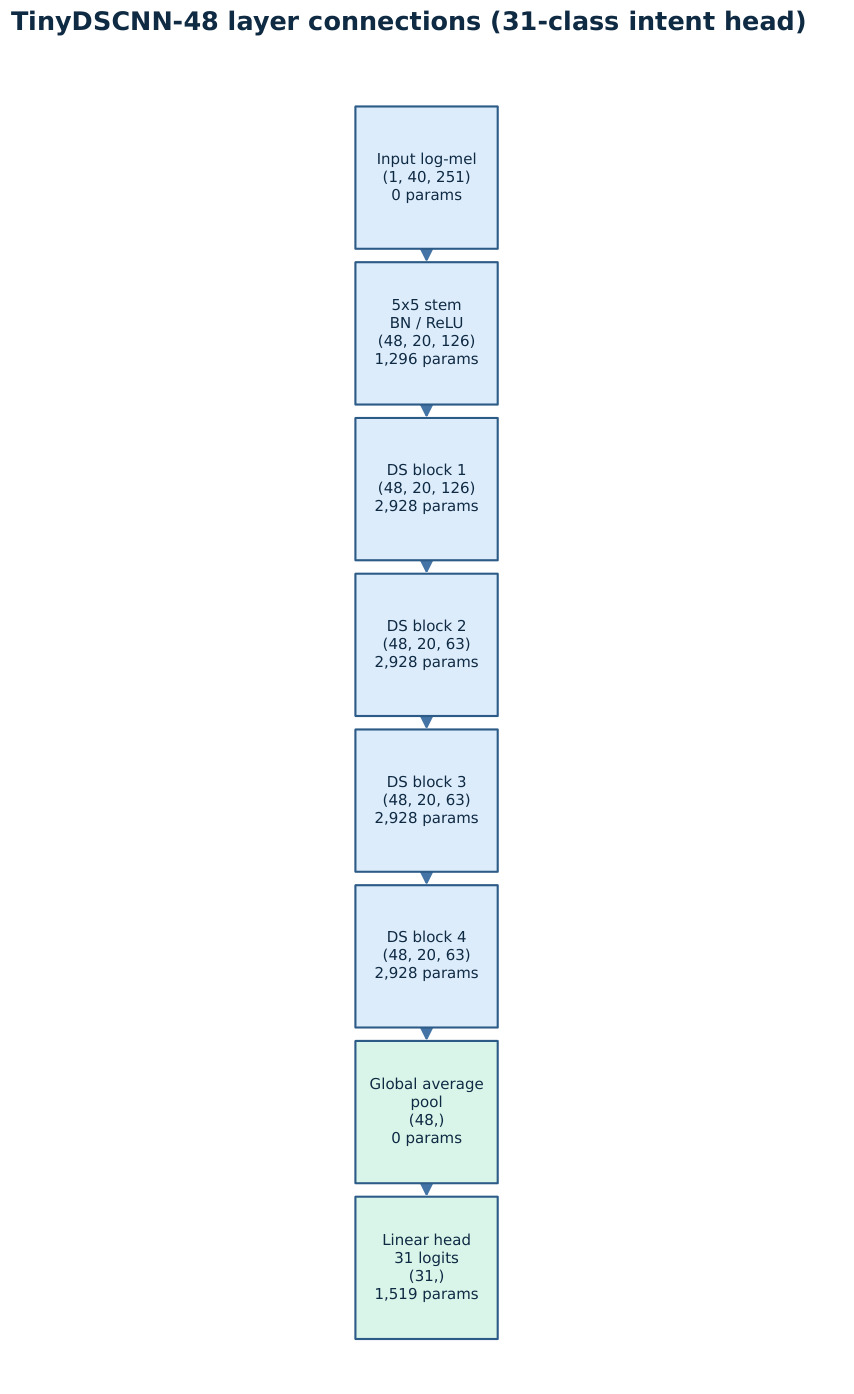

In [3]:
architecture = json.loads((ROOT / 'docs/ME2_ARCHITECTURE_VERIFIED.json').read_text(encoding='utf-8'))
display(pd.DataFrame(architecture['intent_stages'], columns=['stage','output shape','parameters']))
print('Wake parameters:', architecture['wake_parameters'], 'Intent parameters:', architecture['intent_parameters'])
display(Image(filename=str(ROOT / 'docs/ME2_TinyDSCNN48_connections_preview.png')))


## Reproduce from random initialization

Set `RETRAIN = True` for a new scratch run. Epoch progress prints live. On completion the script updates `deployment/current_vcm/`, prepares the package and syncs it to the Pi; use `--train-only` only to explicitly skip deployment. If the Pi is offline the package is pending and training exits with deployment status code 3. The Desktop launcher retries sync when the Pi reconnects. Keep a fresh speaker completely held out for generalization tests.

In [4]:
RETRAIN = False
WAKE_ONLY = False  # True only when no new intent clips have been added
if RETRAIN:
    stamp = pd.Timestamp.now().strftime('%Y%m%d-%H%M%S')
    run_name = f'me2-vcm-notebook-{stamp}'
    command = [sys.executable, '-u', str(ROOT / 'scripts/train_me2_vcm.py'),
               '--run-name', run_name]
    if WAKE_ONLY: command.append('--wake-only')
    print('Starting a new scratch run:', ' '.join(command), flush=True)
    subprocess.run(command, cwd=ROOT, check=True)
    META = json.loads((STAGED / 'metadata.json').read_text(encoding='utf-8'))
    RUN = ROOT / 'runs' / run_name
    REPORT = json.loads((RUN / 'final_evaluation.json').read_text(encoding='utf-8'))
else:
    print('Using the saved active evaluation. Set RETRAIN=True for another scratch run.')
intent_report = REPORT['intent_model_comparison']['personalized_int8']
reference_report = intent_report['optionb_test']
personal_report = intent_report['personal_heldout_test']
print('Active run:', RUN)
print(f"Reference test accuracy: {reference_report['accuracy']:.4%}")
print(f"Personal clip-holdout accuracy: {personal_report['accuracy']:.4%} (n={personal_report['count']})")


Using the saved active evaluation. Set RETRAIN=True for another scratch run.
Active run: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\Dumalaog_ME2 - Tiny Voice Command Model\runs\me2-vcm-20261001-wake-refresh
Reference test accuracy: 96.8854%
Personal clip-holdout accuracy: 92.1739% (n=115)


## Saved epoch progress and checkpoint selection

These histories belong to the selected evaluation candidate above. Checkpoint selection uses validation scores. The wake threshold selected by validation and the fixed 0.95 staged operating cutoff are reported separately; do not treat either as an accuracy percentage.

The manifest snapshot freezes the corpus before training. For wake-only runs, the intent history belongs to the retained source run printed below.


Pair provenance: {'wake': {'training': 'from_random_initialization', 'source_run': 'me2-vcm-20261001-wake-refresh'}, 'intent': {'training': 'retained_byte_identical', 'source_run': 'me2-vcm-20261001-human936', 'int8_sha256': '12984401fe312758dbd7ecd53ae9358b0a41b27ffcd024a9ae263614e2e7b977'}}


,epoch,train_loss,val_zero_FA_wake_recall,val_threshold
0,1,0.124365,0.555556,0.985148
1,2,0.038928,0.777778,0.886058
2,3,0.020687,0.000000,1.000000
3,4,0.013110,1.000000,0.990089
4,5,0.006249,1.000000,0.981531
5,6,0.007525,1.000000,0.851950
6,7,0.010268,0.666667,0.999899
7,8,0.010389,1.000000,0.759708
8,9,0.007094,1.000000,0.823343
9,10,0.002795,1.000000,0.973935


,epoch,train_loss,val_reference_macro_f1,val_reference_min_class_f1,val_personal_macro_f1,checkpoint_score
0,1,2.879895,0.134211,0.000000,0.184219,0.112369
1,2,2.175060,0.366110,0.000000,0.226165,0.278893
2,3,1.590694,0.494330,0.032787,0.292230,0.381812
3,4,1.223120,0.484032,0.090909,0.269250,0.383929
4,5,1.009307,0.697638,0.372093,0.540848,0.616850
5,6,0.860161,0.742870,0.441558,0.631679,0.671489
6,7,0.738511,0.790825,0.620690,0.695043,0.747220
7,8,0.659641,0.725485,0.440816,0.452842,0.641287
8,9,0.596373,0.824474,0.690909,0.633156,0.778629
9,10,0.537265,0.842135,0.636364,0.756934,0.792461


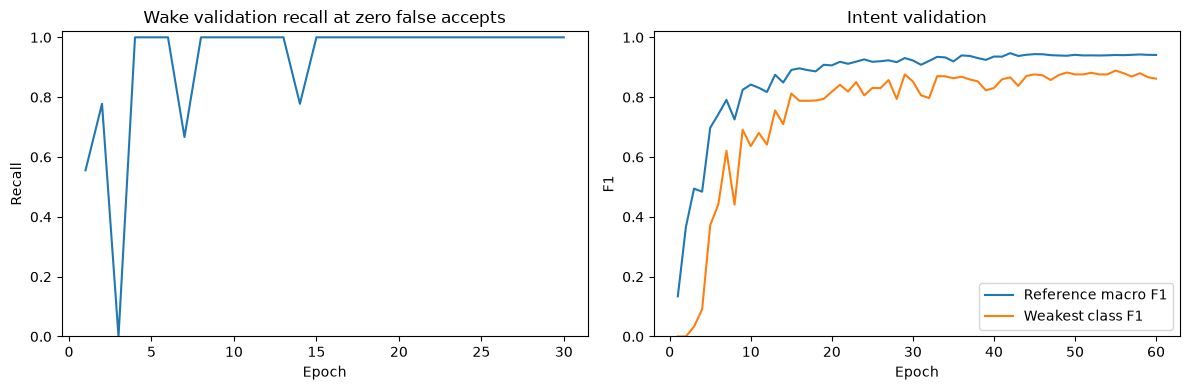

In [5]:
print('Pair provenance:', META.get('pair_provenance', {'note':'full scratch pair'}))
wake_history = pd.DataFrame(json.loads((RUN / 'wake_binary/history.json').read_text(encoding='utf-8'))['history'])
intent_history = pd.DataFrame(json.loads((RUN / 'intent_personalized/history.json').read_text(encoding='utf-8'))['history'])
macro_col = next(c for c in intent_history if c.startswith('val_') and c.endswith('_macro_f1') and 'personal' not in c)
minimum_col = next(c for c in intent_history if c.endswith('_min_class_f1'))
intent_history = intent_history.rename(columns={macro_col:'val_reference_macro_f1',minimum_col:'val_reference_min_class_f1'})
display(wake_history[['epoch','train_loss','val_zero_FA_wake_recall','val_threshold']])
intent_columns = [c for c in ('epoch','train_loss','val_reference_macro_f1','val_reference_min_class_f1','val_personal_macro_f1','checkpoint_score') if c in intent_history]
display(intent_history[intent_columns])
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(wake_history.epoch, wake_history.val_zero_FA_wake_recall); axes[0].set(title='Wake validation recall at zero false accepts',xlabel='Epoch',ylabel='Recall',ylim=(0,1.02))
axes[1].plot(intent_history.epoch, intent_history.val_reference_macro_f1,label='Reference macro F1');
if 'val_reference_min_class_f1' in intent_history: axes[1].plot(intent_history.epoch,intent_history.val_reference_min_class_f1,label='Weakest class F1')
axes[1].set(title='Intent validation',xlabel='Epoch',ylabel='F1',ylim=(0,1.02)); axes[1].legend(); plt.tight_layout(); display(fig); plt.close(fig)


## Frozen INT8 evaluation and operating threshold

The tables show the active pair's reference and personal scores. No test results are used to tune a threshold here. The Pi uses the fixed 0.95 wake cutoff. The near-one validation cutoff remains in the historical evaluation as a separate measurement; neither score establishes false wake activations per hour.

In [6]:
candidate_wake = REPORT['wake_model_comparison']['binary']
candidate_intent = REPORT['intent_model_comparison']['personalized_int8']
reference = candidate_intent['optionb_test']
personal = candidate_intent['personal_heldout_test']
wake_table = pd.DataFrame([{
    'candidate validation threshold': candidate_wake['validation_selected_int8_threshold'],
    'held-out personal wake hits': f"{candidate_wake['heldout_personal_wake_hits']}/{candidate_wake['heldout_personal_wake_support']}",
    'false accepts / reference commands': f"{candidate_wake['false_wake_on_optionb_command_clips']}/{candidate_wake['optionb_command_support']}",
    'false accepts / personal non-wake': f"{candidate_wake['false_wake_on_personal_nonwake_clips']}/{candidate_wake['personal_nonwake_support']}"
}])
display(wake_table)
display(pd.DataFrame([{
    'reference accuracy': reference['accuracy'],
    'reference macro F1': reference['classification_report']['macro avg']['f1-score'],
    'personal accuracy': personal['accuracy'],
    'personal macro F1': personal['classification_report']['macro avg']['f1-score'],
    'personal test clips': personal['count']
}]))
classes = pd.DataFrame([{'class': label, **row} for label,row in reference['classification_report'].items()
                        if label not in ('accuracy','macro avg','weighted avg')])
classes = classes.rename(columns={'f1-score':'f1'})
classes['meets 95% precision, recall and F1'] = (classes['precision'] >= .95) & (classes['recall'] >= .95) & (classes['f1'] >= .95)
display(classes)
print('Reference classes below 95% F1:', classes.loc[classes['f1'] < .95,'class'].tolist())
print('Offline intent metrics: argmax. Live acceptance: confidence >= 0.68 and top-two margin >= 0.15 for all classes.')

point = META['wake']['operating_point_replay']
display(pd.DataFrame([{'deployed wake threshold':point['threshold'],
    'wake hits':f"{point['personal_wake_hits']}/{point['personal_wake_support']}",
    'personal false accepts':f"{point['personal_nonwake_false_accepts']}/{point['personal_nonwake_support']}",
    'reference false accepts':f"{point['dataset_command_false_accepts']}/{point['dataset_command_support']}"}]))


,candidate validation threshold,held-out personal wake hits,false accepts / reference commands,false accepts / personal non-wake
0,0.997544,10/11,0/1798,0/136


,reference accuracy,reference macro F1,personal accuracy,personal macro F1,personal test clips
0,0.968854,0.968993,0.921739,0.924386,115


,class,precision,recall,f1,support,"meets 95% precision, recall and F1"
0,ALARM_6_00AM,1.000000,0.948276,0.973451,58.0,False
1,ALARM_8_00AM,0.933333,1.000000,0.965517,56.0,False
2,ALARM_9_00PM,0.982759,0.982759,0.982759,58.0,True
3,BRIGHTNESS_100,0.893939,0.983333,0.936508,60.0,False
4,BRIGHTNESS_20,0.981481,0.883333,0.929825,60.0,False
5,BRIGHTNESS_60,1.000000,1.000000,1.000000,60.0,True
6,CALL,0.946429,0.981481,0.963636,54.0,False
7,COLOR_BLUE,1.000000,0.950000,0.974359,60.0,True
8,COLOR_GREEN,1.000000,0.983333,0.991597,60.0,True
9,COLOR_RED,0.967742,1.000000,0.983607,60.0,True


Reference classes below 95% F1: ['BRIGHTNESS_100', 'BRIGHTNESS_20', 'TEMPERATURE_18', 'TEMPERATURE_22', 'TIME']
Offline intent metrics: argmax. Live acceptance: confidence >= 0.68 and top-two margin >= 0.15 for all classes.


,deployed wake threshold,wake hits,personal false accepts,reference false accepts
0,0.95,11/11,0/136,0/1798


In [7]:
for kind in ('wake','intent'):
    model = META[kind]['model']
    path = STAGED / model['path']
    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    assert actual == model['sha256']
    print('active', kind, path.name, path.stat().st_size, 'bytes', actual)
print('Combined ONNX size:', sum(META[k]['model']['size_bytes'] for k in ('wake','intent')), 'bytes')
latest = json.loads((ROOT / 'deployment/latest_release.json').read_text(encoding='utf-8'))
receipt = json.loads((ROOT / 'deployment/last_pi_deployment.json').read_text(encoding='utf-8'))
print('Last synchronization status:', latest['status'], latest['source_run'])
print('Verified Pi path:', receipt['installed_at'])
print('Pi CPU benchmark:', receipt['verification']['model_results'])
print('These files record the last deployment check. Consult the live API before a new hardware trial.')


active wake binary_wake_int8.onnx 37425 bytes 6c2e941580d8ea778ed664c929e893c226efb91e3e787e65837908c81153deac
active intent intent_int8.onnx 39315 bytes 12984401fe312758dbd7ecd53ae9358b0a41b27ffcd024a9ae263614e2e7b977
Combined ONNX size: 76740 bytes
Last synchronization status: pending me2-vcm-20261001-wake-refresh
Verified Pi path: /home/dalmacio/Desktop/dandan
Pi CPU benchmark: [{'file': 'models/wake_binary_int8.onnx', 'bytes': 37425, 'classes': 2, 'providers': ['CPUExecutionProvider'], 'model_only_ms': {'p50': 1.351, 'p95': 1.397}, 'frontend_plus_model_ms': {'p50': 5.442, 'p95': 5.781}}, {'file': 'models/intent_31_int8.onnx', 'bytes': 39315, 'classes': 31, 'providers': ['CPUExecutionProvider'], 'model_only_ms': {'p50': 1.346, 'p95': 1.391}, 'frontend_plus_model_ms': {'p50': 5.169, 'p95': 5.33}}]
These files record the last deployment check. Consult the live API before a new hardware trial.


## New dataset candidate comparison — 2026-10-02

This isolated intent candidate was trained from random initialization on the ME2 Spoken Command Dataset. Checkpoint selection and the 0.76 confidence / 0.00 margin no-action gate used only a source/speaker-group validation split carved from train. Its frozen 4,418-row test was scored once after freezing the model, gates, hashes, and scorer.

The wake model is byte-identical to the active two-class wake model because the dataset has no wake-positive examples. The Pi candidate is separately installed at /home/dalmacio/Desktop/me2-dataset-candidate and loopback port 7865. It does not replace the normal /home/dalmacio/Desktop/dandan release.

,Accuracy,Macro F1
Model,,
Current,79.64%,79.47%
Dataset candidate,78.95%,79.12%


Best validation checkpoint: epoch 82 (accuracy 78.09%, macro F1 78.72%)
INT8 candidate: 39,315 bytes; validation FP32/INT8 agreement: 95.63%


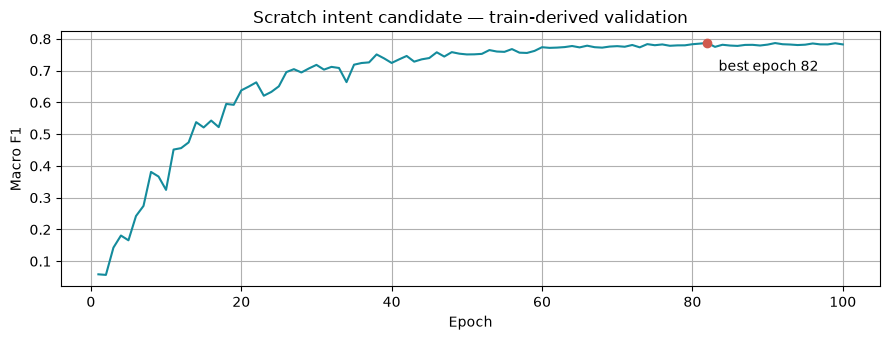

,Current F1,Candidate F1,Change (pp),Support
Label,,,,
ALARM_6_00AM,86.0%,83.2%,-2.87,141
ALARM_8_00AM,72.6%,87.2%,+14.65,141
ALARM_9_00PM,76.4%,92.1%,+15.76,141
BRIGHTNESS_100,88.6%,89.9%,+1.30,141
BRIGHTNESS_20,92.4%,90.5%,-1.91,141
BRIGHTNESS_60,96.4%,96.4%,+0.00,141
CALL,67.5%,72.1%,+4.51,141
COLOR_BLUE,79.7%,66.4%,-13.25,141
COLOR_GREEN,80.1%,78.9%,-1.20,141


Pi state: running_isolated_candidate; verified install path: /home/dalmacio/Desktop/me2-dataset-candidate.
Pi microphone: No microphone connected; live speech test remains pending.
Paired Pi intent URL: http://127.0.0.1:7865/assistant


In [8]:
CANDIDATE_RUN = ROOT / 'runs/classagreementvcm-20261002-a90b8d10-r3'
CANDIDATE_META = json.loads((CANDIDATE_RUN / 'candidate_metadata.json').read_text(encoding='utf-8'))
CANDIDATE_TEST = json.loads((CANDIDATE_RUN / 'frozen_test_comparison.json').read_text(encoding='utf-8'))
CANDIDATE_HISTORY = json.loads((CANDIDATE_RUN / 'training_history.json').read_text(encoding='utf-8'))
PI_TRIAL = json.loads((ROOT / 'deployment/classagreementvcm_candidate_deployment.json').read_text(encoding='utf-8'))

best_epoch = max(CANDIDATE_HISTORY, key=lambda row: row['validation_supported_macro_f1'])
display(pd.DataFrame([
    {'Model': 'Current', 'Accuracy': CANDIDATE_TEST['baseline']['raw_supported']['accuracy'],
     'Macro F1': CANDIDATE_TEST['baseline']['raw_supported']['macro_f1']},
    {'Model': 'Dataset candidate', 'Accuracy': CANDIDATE_TEST['candidate']['raw_supported']['accuracy'],
     'Macro F1': CANDIDATE_TEST['candidate']['raw_supported']['macro_f1']},
]).set_index('Model').style.format('{:.2%}'))
print(f"Best validation checkpoint: epoch {best_epoch['epoch']} "
      f"(accuracy {best_epoch['validation_supported_accuracy']:.2%}, "
      f"macro F1 {best_epoch['validation_supported_macro_f1']:.2%})")
quant = json.loads((CANDIDATE_RUN / 'quantization_validation.json').read_text())
print(f"INT8 candidate: {CANDIDATE_META['intent_model']['int8_bytes']:,} bytes; "
      f"validation FP32/INT8 agreement: {quant['candidate_fp32_int8_prediction_parity']:.2%}")

curve = pd.DataFrame(CANDIDATE_HISTORY)
ax = curve.plot(x='epoch', y='validation_supported_macro_f1', figsize=(9, 3.5),
                legend=False, color='#148b9c', grid=True)
ax.scatter([best_epoch['epoch']], [best_epoch['validation_supported_macro_f1']], color='#d05a4e', zorder=3)
ax.set(title='Scratch intent candidate — train-derived validation', xlabel='Epoch', ylabel='Macro F1')
ax.annotate(f"best epoch {best_epoch['epoch']}",
            (best_epoch['epoch'], best_epoch['validation_supported_macro_f1']),
            xytext=(8, -20), textcoords='offset points')
plt.tight_layout()
plt.show()

class_rows = []
for label, row in CANDIDATE_TEST['per_class'].items():
    class_rows.append({
        'Label': label,
        'Current F1': row['baseline_f1'],
        'Candidate F1': row['candidate_f1'],
        'Change (pp)': row['baseline_candidate_f1_delta_pp'],
        'Support': row['support'],
    })
class_scores = pd.DataFrame(class_rows).set_index('Label')
display(class_scores.style.format({'Current F1':'{:.1%}', 'Candidate F1':'{:.1%}', 'Change (pp)':'{:+.2f}'}))
print(f"Pi state: {PI_TRIAL['status']}; verified install path: {PI_TRIAL['install_path']}.")
print(f"Pi microphone: {PI_TRIAL['pi_verification']['microphone']}; live speech test remains pending.")
print(f"Paired Pi intent URL: {PI_TRIAL['local_loopback_url']}")